Car Price Prediction and Exploratory Data Analysis

Author: Letswaletje Michelle Matjie

This project demonstrates my ability to perform data cleaning, exploratory data analysis (EDA), feature engineering, data visualization, and machine learning model development using Python.The objective of this project is to explore the factors that influence vehicle selling prices and develop predictive models capable of estimating vehicle values accurately. The project demonstrates key data science skills, including data cleaning, exploratory data analysis (EDA), feature engineering, data visualization, and machine learning model development.


In [ ]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression

sns.set(style="whitegrid")
df = pd.read_csv("car_price_dataset.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
#Showing the shape (number of rows and columns of the dataset)
print("\nSHAPE OF DATASET(rows, columns):")
df.shape


SHAPE OF DATASET(rows, columns):


(15411, 14)

In [ ]:
# Displaying the first five rows of the dataset
print("\nFIRST 5 ROWS OF THE DATASET:\n")
df.head()


FIRST 5 ROWS OF THE DATASET:



,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
# Displaying the last five rows of the dataset
print("\nLAST 5 ROWS OF THE DATASET:\n")
df.tail()


LAST 5 ROWS OF THE DATASET:



,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


**OBSERVATIONS:**

The dataset contains 15411 rows and 14 columns. The first and last few rows show typical car details such as their make, model, and type of petrol they use.

In [ ]:
#2.1
print("\nDATASET INFORMATION:\n")
df.info()


DATASET INFORMATION:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


The dataset has no missing values, there will  be minimal data cleaning needed for missing data handling.
Since the dataset is a mixture of categorical and numerical variables, encoding will be needed for the categorical ones like brand, fuel_type, etc.
Columns like "Unnamed:0" are index columns and will be dropped as it doesn’t contribute to predictions nor add analytical value.

In [ ]:
# Checking data types
print("\nDATA TYPES OF COLUMNS:\n")
df.dtypes


DATA TYPES OF COLUMNS:



,0
Unnamed: 0,int64
car_name,object
brand,object
model,object
vehicle_age,int64
km_driven,int64
seller_type,object
fuel_type,object
transmission_type,object
mileage,float64


In [ ]:
 # Convert object columns with repeated categories to 'category'
categorical_cols = ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
df[categorical_cols] = df[categorical_cols].astype('category')

print("\n Data types updated where necessary!")
df.dtypes


 Data types updated where necessary!


,0
Unnamed: 0,int64
car_name,object
brand,category
model,category
vehicle_age,int64
km_driven,int64
seller_type,category
fuel_type,category
transmission_type,category
mileage,float64


**Project Rationale**

I converted Columns (e.g, fuel type) that had repeated categories from 'object' to 'category' to save memory and to speed up analysing. Numeric columns stay the same since they are better suited for calculations.

In [ ]:
#2.3 Generate summary statistics for the numerical columns and interpret what these statistics tell you about the data.
print("\nSUMMARY OF STATISTICS\n")
df.describe()


SUMMARY OF STATISTICS



,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


This statistics summary shows that the dataset has 15 411 entries. Most cars are around 6 years old, with 55 000 km driven and 5 seats and this is all derived from the mean. However, some values seem to be unrealistic or rather over exaggerated, such as 3.8 million km driven and 0 seats. Selling prices range widely, with a few luxury car outliers. These outliers and incorrect entries will need cleaning before analysis.

In [ ]:
#The dataset has 15 411 entries. Most cars are around 6 years old, with 55 000 km driven and 5 seats and this is all derived from the mean.
#But there are some discrepancies when it comes to numerical features, categorical features, and the data quality.
#Columns like km driven show some values that indicate entry errors like 3,8 million km.
#Then columns such as the brand and fuel type of the car are catergorical not objects since they are traits of the car.
#Outliers such as extreme values for km driven can possibly skew the analysis and incorect entries like 0 seats need to be corrected or removed.

In [ ]:
# Identify missing values in the dataset
df.isnull().sum()


,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


In [ ]:
#dropping the "Unnamed: 0" column
df.drop("Unnamed: 0", axis=1, inplace=True)
print("\nColumn 'Unnamed: 0' dropped.")
# Handling Missing Values
print("\nMissing values in each column:\n", df.isnull().sum())
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df.fillna({col: df[col].median()}, inplace=True)
    else:
        # Access the mode value correctly using .iloc[0] or [0]
        df.fillna({col: df[col].mode().iloc[0]}, inplace=True)
print("\n Missing values handled successfully!")


Column 'Unnamed: 0' dropped.

Missing values in each column:
 car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

 Missing values handled successfully!


In [ ]:
# Handling Duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("\n Duplicates removed. New shape:", df.shape)


Number of duplicate rows: 167

 Duplicates removed. New shape: (15244, 13)


Duplicates can alter the analysis by over-representing some of the observations, so removing them ensures the integrity of data and accuracy of the statistical results. I first dropped the Unnamed: 0 column as it doesn't sere any analytical value to the dataset. Then I removed the duplicates (167) to get a clean dataset that now has 15244 rows and 13 columns.


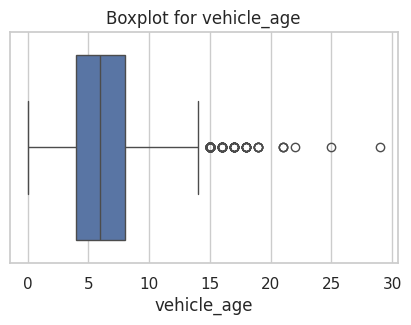

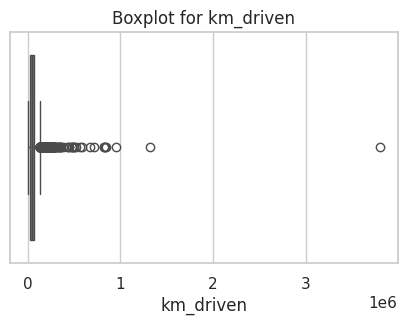

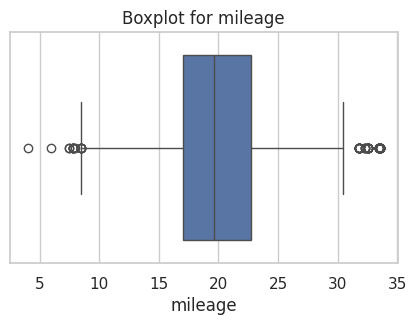

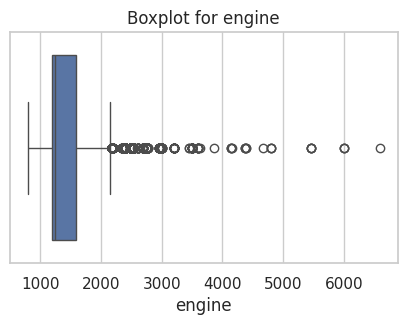

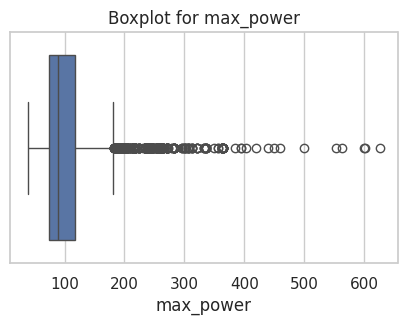

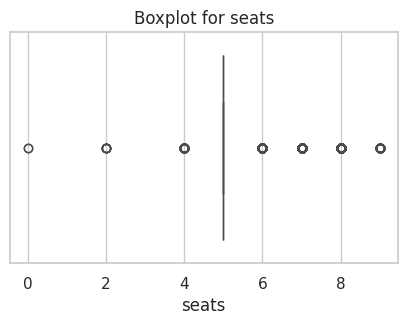

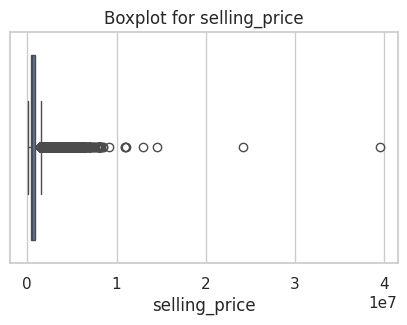

In [ ]:
# Outlier detection and removal
numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()


In [ ]:
# Remove outliers using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\n Outliers handled. New shape:", df.shape)


 Outliers handled. New shape: (10960, 13)


In [ ]:
# In a boxplot,points that fall outside the "whiskers" are called outliers.
# The Boxplots above show extreme values as points beyond the whiskers.
# Columns like 'km_driven', 'engine', 'max_power', and 'selling_price' have really noticeable outliers.
# Outliers were removed using the IQR method.
# This inturn reduced extreme values, which made the dataset more reliable for analysis and modeling.


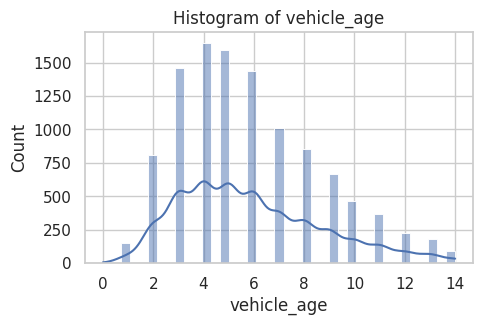

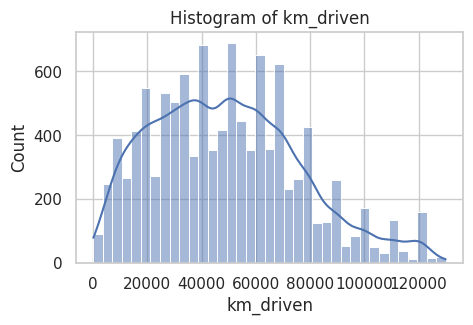

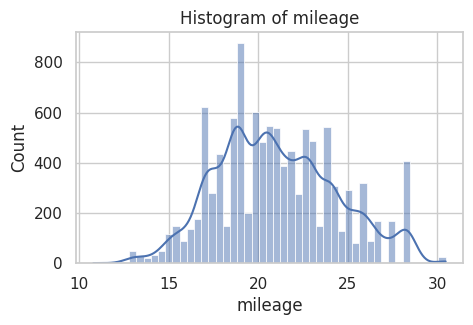

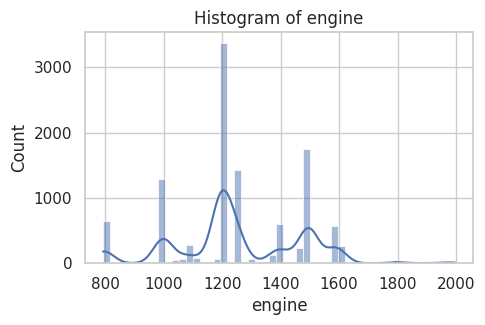

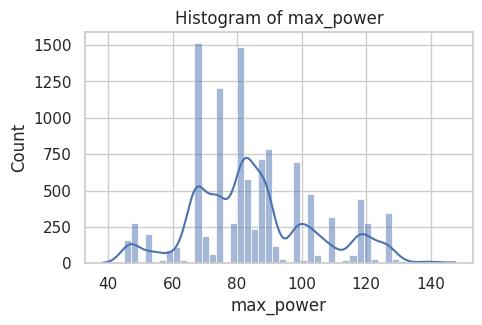

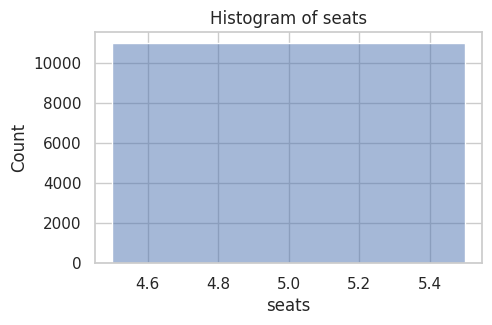

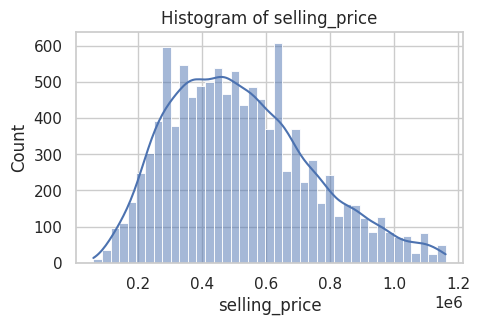

In [ ]:
# Univariate Analysis
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

**INSIGHTS**
- Most cars are around 3–6 years old, as seen by the peak in the 'vehicle_age' histogram.
- 'km_driven' are right-skewed, with most cars having <600,000 km but a few extreme high values going into the millions.
- 'mileage' shows a normal distribution clustered around ~20 km/l, which shows typical car efficiency.
- 'engine' and 'max_power' are slightly right-skewed due to some high-performance vehicles.
- 'selling_price' is right-skewed, with a few very expensive cars that act as outliers.


In [ ]:
# Skewness Check
numerical_cols = df.select_dtypes(include=np.number).columns
print("\nSkewness of numerical columns:\n", df[numerical_cols].skew())
# Features with skewness greater than ±1 were log-transformed to normalize their distribution.
for col in numerical_cols:
    if abs(df[col].skew()) > 1:
        df[col] = np.log1p(df[col])
print("\n Skewness handled where necessary.")


Skewness of numerical columns:
 vehicle_age      0.682200
km_driven        0.477708
mileage          0.275920
engine          -0.011383
max_power        0.444041
seats            0.000000
selling_price    0.533415
dtype: float64

 Skewness handled where necessary.


In [ ]:
# Standardization
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("\n Numerical columns standardized.")


 Numerical columns standardized.


/tmp/ipython-input-1662370496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette="pastel")


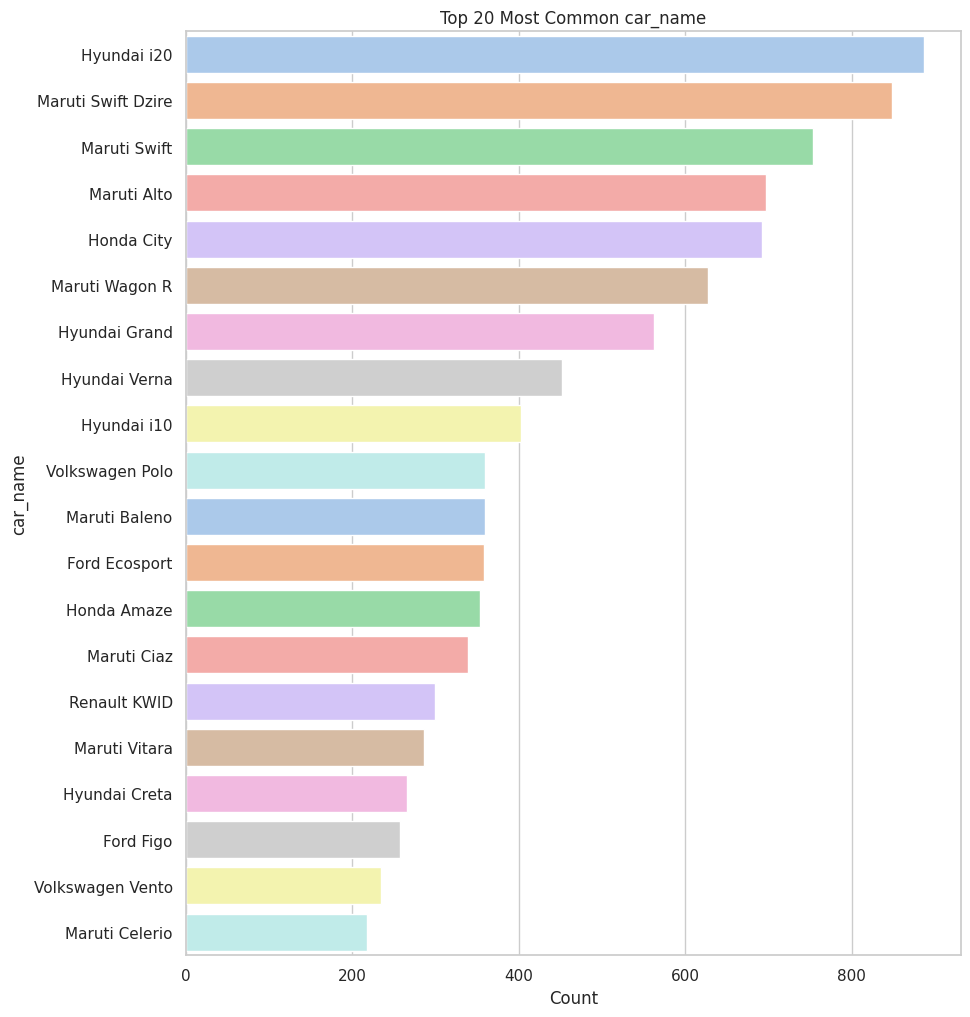

/tmp/ipython-input-1662370496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette="pastel")


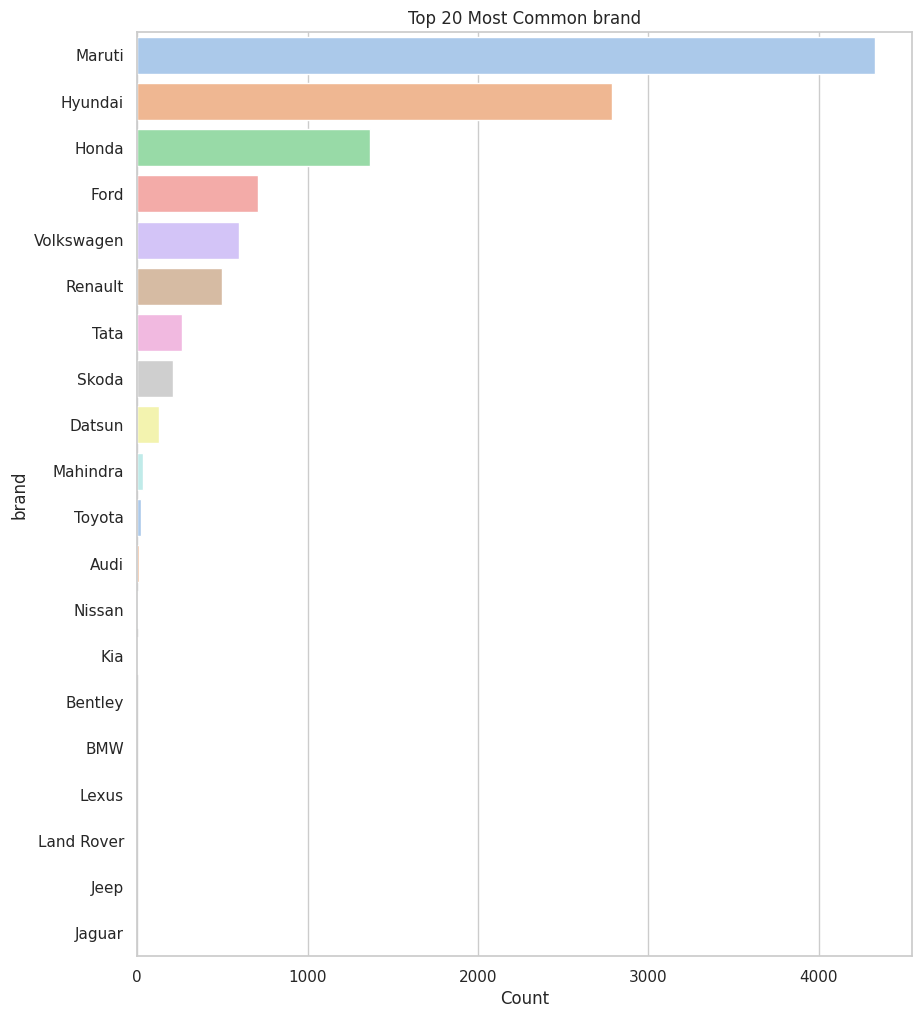

/tmp/ipython-input-1662370496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette="pastel")


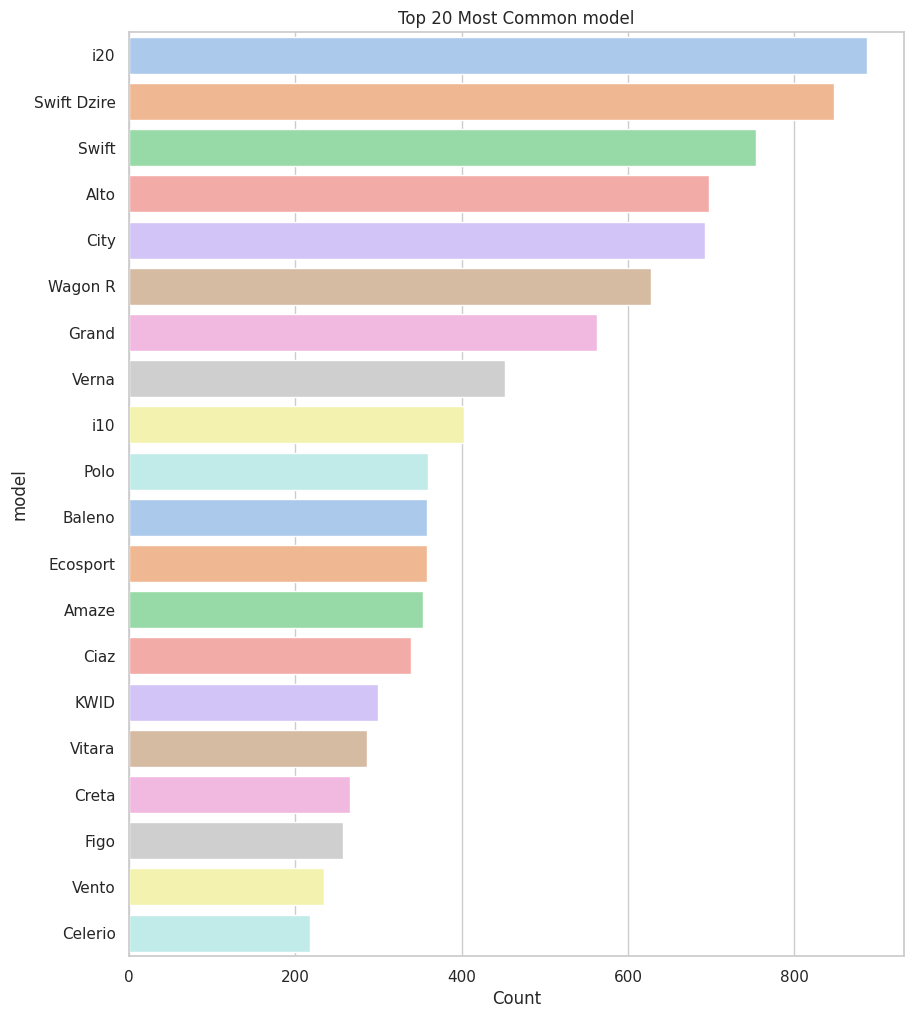

/tmp/ipython-input-1662370496.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette="pastel")


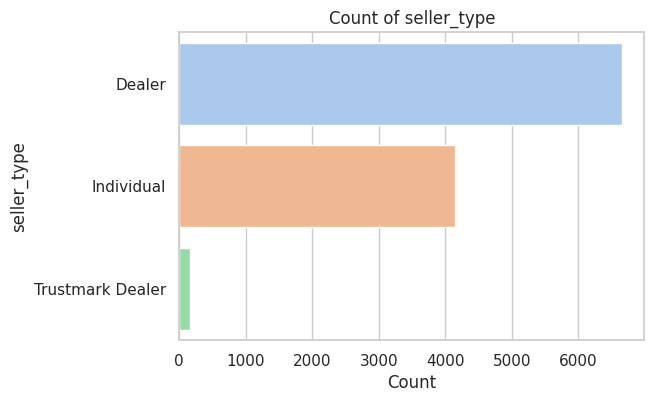

/tmp/ipython-input-1662370496.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette="pastel")


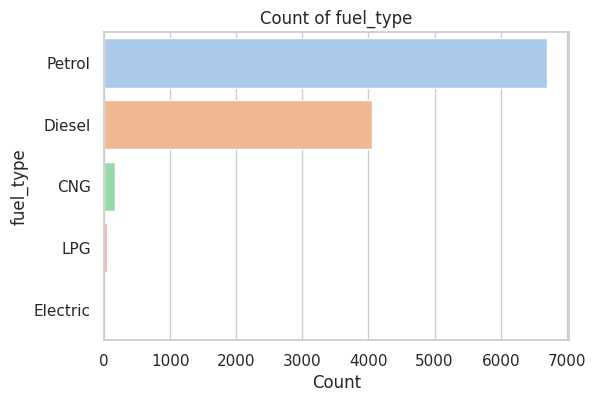

/tmp/ipython-input-1662370496.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette="pastel")


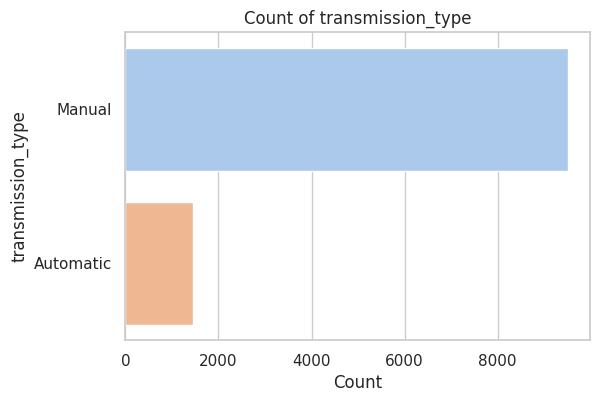

In [ ]:
# UNIVARIATE ANALYSIS: CATEGORICAL FEATURES
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    # Adjust figure size dynamically
    if col in ["car_name", "brand", "model"]:
        plt.figure(figsize=(10, 12))  # Larger for better readability
        top_n = 20  # Show only the top 20 categories
        order = df[col].value_counts().head(top_n).index
        sns.countplot(y=df[col], order=order, palette="pastel")
        plt.title(f"Top {top_n} Most Common {col}")
    else:
        plt.figure(figsize=(6, 4))
        sns.countplot(y=df[col], order=df[col].value_counts().index, palette="pastel")
        plt.title(f"Count of {col}")

    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

**INSIGHTS**

- A few brands such as Maruti and Hyundai dominate the dataset, while other brands appear rarely.
- With Fuel type, Petrol cars are the most common followed by diesel whereas electric and LPG cars are rare.
- Trustmark Dealers make up a smaller portion of seller type since most cars are sold by Dealers.
- Manual cars dominate the dataset over automatic cars.


In [ ]:
# Encode Categorical Features
categorical_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print("\n Categorical features encoded.")


 Categorical features encoded.


In [ ]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()
print("\nCORRELATION MATRIX:\n")
df[numerical_cols].corr()


CORRELATION MATRIX:



,car_name,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
car_name,1.000000,-0.028223,0.016946,0.135036,-0.221922,-0.243495,NaN,-0.093160
vehicle_age,-0.028223,1.000000,0.503000,-0.262998,0.048104,-0.053784,NaN,-0.632066
km_driven,0.016946,0.503000,1.000000,0.060123,0.232784,0.089970,NaN,-0.247222
mileage,0.135036,-0.262998,0.060123,1.000000,-0.204358,-0.324050,NaN,0.043991
engine,-0.221922,0.048104,0.232784,-0.204358,1.000000,0.870035,NaN,0.488179
max_power,-0.243495,-0.053784,0.089970,-0.324050,0.870035,1.000000,NaN,0.572878
seats,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
selling_price,-0.093160,-0.632066,-0.247222,0.043991,0.488179,0.572878,NaN,1.000000


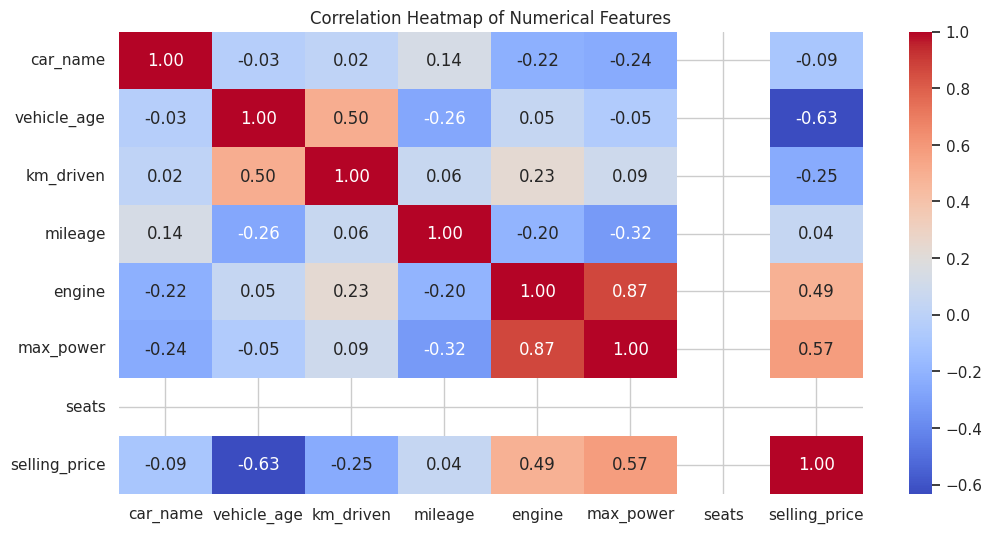

In [ ]:
# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:
if 'selling_price' in df.columns:
    print("\nTop correlations with Selling Price:\n")
    print(corr_matrix['selling_price'].sort_values(ascending=False))



Top correlations with Selling Price:

selling_price    1.000000
max_power        0.572878
engine           0.488179
mileage          0.043991
car_name        -0.093160
km_driven       -0.247222
vehicle_age     -0.632066
seats                 NaN
Name: selling_price, dtype: float64


**DESCRIPTION OF EVIDENT RELATIONSHIPS**
- 'engine' and 'max_power' show a strong positive correlation, because higher engine capacity almost always equals higher power.
- 'selling_price' is positively correlated with 'engine', 'max_power', and 'seats', showing that cars with more space and power tend to be more expensive.
- 'km_driven' has a weak negative correlation with 'selling_price',
meaning cars with higher mileage generally sell for less as they are run down compared to new ones.
- 'vehicle_age' is negatively correlated with 'selling_price', indicating that older cars tend to be cheaper.


**Detailed Observations and Conclusions**

- Cars with bigger engines and more power generally cost more. This makes sense because buyers are willing to pay extra for better performance.

- Older cars and those with high mileage are cheaper, which is expected since they lose value over time and might need more maintenance.

- The patterns we see in the data match real-life car market trends, which means the dataset seems reliable and realistic.

- If we were to build a price prediction model, engine size, max power, and vehicle age would probably be the most important factors in determining a car’s selling price.

In [ ]:
# FEATURE SELECTION USING CORRELATION

if 'selling_price' in df.columns:
    numeric_df = df.select_dtypes(include=['int64', 'float64'])  # Only numeric columns
    corr_with_price = numeric_df.corr()['selling_price'].sort_values(ascending=False)
    print("\nTop correlations with Selling Price:\n", corr_with_price)

# Features with moderate to strong correlation (e.g., >0.3 or <-0.3)
# are considered more relevant for predicting selling price.



Top correlations with Selling Price:
 selling_price    1.000000
max_power        0.572878
engine           0.488179
mileage          0.043991
car_name        -0.093160
km_driven       -0.247222
vehicle_age     -0.632066
seats                 NaN
Name: selling_price, dtype: float64


In [ ]:
# FEATURE SELECTION USING K HIGHEST SCORES

from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop("selling_price", axis=1)  # All features except target
y = df["selling_price"]

bestfeatures = SelectKBest(score_func=f_regression, k=5)  # Select top 5
fit = bestfeatures.fit(X, y)

# Create DataFrame to display scores
df_scores = pd.DataFrame(fit.scores_)
df_columns = pd.DataFrame(X.columns)
featureScores = pd.concat([df_columns, df_scores], axis=1)
featureScores.columns = ["Feature", "Score"]

print("\nTop 5 Selected Features:\n", featureScores.nlargest(5, "Score"))


Top 5 Selected Features:
               Feature        Score
3         vehicle_age  7290.371138
10          max_power  5353.148540
9              engine  3428.600638
4           km_driven   713.338092
7   transmission_type   689.648251


In [ ]:
# Selected features based on highest K-score
X = df[['vehicle_age', 'max_power', 'engine', 'km_driven', 'transmission_type']]

**INSIGHTS**

- 'max_power'is the strongest predictor of 'selling_price' because powerful cars are more expensive.
- Larger engines are usually found in higher-end cars which increases the price.
- 'vehicle_age' indicates a negative relationship since newer cars are more expensive.
- 'km_driven' shows a slight negative influence because high mileage lowers resale value.
- 'Transmission type' has a higher K-score and thus is a good feature because Automatic cars tend to be newer models and consumers tend to prefer automatic cars over manual cars, with this being one of the key features consumers tend to require for a new car.


# **Section 6:** **Model Selection and Training**

# **6.1 Three different machine learning algorithms to train on the dataset.**

- Linear Regression
- Random Forest
- XGBOOST

# **Linear Regression**

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#create a linear regression model

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# **Random Forest**

Hyperparameter Tuning via GridSearchCV

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# **XGBoost Regressor**

Hyperparameter Tuning via RandomizedSearchCV

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist_xgb = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

random_xgb = RandomizedSearchCV(xgb, param_dist_xgb, cv=5, scoring='r2', n_jobs=-1, n_iter=10)
random_xgb.fit(X_train, y_train)
best_xgb = random_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

# **Section 7**: **Model Evaluation:**
Evaluation metrics:
- RMSE,
- MAE,
- R-square

In [ ]:
# mean_squared_error returns MSE; sqrt → RMSE
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

rmse_lr = np.sqrt(mse_lr)
rmse_rf = np.sqrt(mse_rf)
rmse_xgb  = np.sqrt(mse_xgb)

r2_lr = r2_score(y_test, y_pred_lr)
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb  = r2_score(y_test, y_pred_xgb)

# --------------------------------------------------------------
# 3. Assemble everything in a single DataFrame
# --------------------------------------------------------------

metrics_df = pd.DataFrame({
    'Model':              ['Linear Regression', 'Random Forest', 'XGBOOST'],
    'MSE':                [mse_lr, mse_rf, mse_xgb],
    'RMSE':               [rmse_lr, rmse_rf, rmse_xgb],
    'R²':                 [r2_lr, r2_rf, r2_xgb]
})

# round for readability
metrics_df = metrics_df.round({'MSE': 1, 'RMSE': 2, 'R²': 3})

metrics_df

,Model,MSE,RMSE,R²
0,Linear Regression,0.3,0.54,0.712
1,Random Forest,0.1,0.38,0.861
2,XGBOOST,0.1,0.37,0.868


## Business Recommendations

Based on the findings from this analysis, dealerships can use factors such as vehicle age, mileage, engine size, and power output to make more informed pricing decisions. These characteristics appeared to have a noticeable influence on the selling price of vehicles.

The project also showed the importance of maintaining good-quality data. Unrealistic values and duplicate records can affect analysis results, so businesses should regularly check and clean their data to improve accuracy.

Predictive models like the one developed in this project could assist dealerships in estimating prices for used vehicles more consistently. While these models should not replace human judgement, they can serve as a useful decision-support tool.

Finally, understanding the factors that affect vehicle prices can help dealerships make better purchasing decisions, manage inventory more effectively, and provide customers with clearer explanations of how prices are determined.

##Conclusion

This project successfully demonstrated the end-to-end data science workflow, including data cleaning, exploratory data analysis, feature engineering, visualization, and predictive modeling.

The analysis identified several factors that influence vehicle selling prices, including vehicle age, engine characteristics, and usage-related variables. Multiple machine learning models were evaluated, with ensemble-based approaches such as Random Forest and XGBoost achieving the strongest predictive performance.

The project highlights practical proficiency in Python, data analysis, machine learning, and business-focused problem solving. The findings demonstrate how data-driven techniques can support more accurate vehicle valuation and decision-making processes.

Project Summary

- Cleaned and prepared a dataset of over 15,000 vehicle records.

- Conducted exploratory data analysis and visualization.

- Identified key drivers of vehicle selling prices.

- Applied feature selection techniques.

- Trained and evaluated Linear Regression, Random Forest, and XGBoost models.

- Demonstrated practical skills in Python, machine learning, and business-focused data analysis.

SKILLS DEMOSTRATED:

- Data Collection and Preparation
- Data Cleaning and Validation
- Exploratory Data Analysis (EDA)
- Data Visualization
- Statistical Analysis
- Feature Engineering
- Machine Learning
- Model Evaluation
- Reporting and Documentation
- Business Insight Generation